# 3.18 Pointing -- NIR Focal Plane Mapping

OVERVIEW: Observe a star with moderate brightness at several positions across the NIR array to determine the mapping between the sky and the detector. Data should be taken with the star at the nominal boresight and at multiple locations around the edge of the NIR field of view.


DATA PRODUCTS:
- RD-B2: table that provides mapping between sky and detector positions to quantify field distortions
- RD-B3: table that provides mapping between sky and detector positions to quantify boresign alignment & table that quantifies NIR position relative to VIS


EXIT CRITERIA: observation obtained, analysis complete and summarized in 3.18_ResultsSummary.md


DATA VOLUME: We plan for 10 observations, 5 with a smaller NIR subarray, 5 with a larger NIR subarray.
- NIR & VIS, 2 VIS regions 200x200, one NIR region 84x400 or 512x2048


TARGET CRITERIA: Select one target of moderate brightness, i.e., Pandora Mag ~8-9, Jmag ~7-9. These criteria will be further updated with input from the stakeholders.


KEY STAKEHOLDERS: Christina Hedges

## Load In

In [1]:
''' Make sure you have pandorasim installed and updated '''
import pandorasat as ps
import pandorasim as pp
ps.utils.get_phoenix_model(teff=7000, jmag=10) # this is a temporary fix to an import error with pandorasim
from pandorasim import VisibleSim, NIRSim
from pandorasim import plot_nirda_integrations
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord, Longitude
from astropy.io import fits
from pandorasat.plotting import animate
from pandorasat.plotting import save_mp4, save_gif
from astropy.time import Time, TimeDelta

### Importing additional functions and constants used in this notebook
import sys, os
sys.path.append(os.path.abspath('..'))
from CommissFunctions import generate_task_plan 
from CommissFunctions import data_rate, bits_per_pix_VIS, compression_fractor_VIS, frame_time_VIS, stored_frames_per_int_VIS, pass_time_min, VIS_ra_shape, VIS_dec_shape, NIR_ra_shape, NIR_dec_shape, regions_NIR, bits_per_pix_NIR, compression_fractor_NIR 


In [2]:
''' Define a PandoraSat object for calling constants '''
p = ps.PandoraSat()

## Define Target

In [3]:
### Possible Targets:
# Gaia DR3 3143682556189212672

In [4]:
''' Finds target coordinates based on astropy '''
### You can do this differently as long as you have DEC and RA
target = "G3143682556189212672" # Gaia DR3 3143682556189212672
c = SkyCoord(ra=118.985495, dec=5.825131, unit='deg') # coordinates for "target" from GAIA database with more recent epoch then SkyCoord pulls from name

## Define Array Location Function

In [5]:
''' Function defining the pattern of the target location on the array '''
### This function returns a location to point the telescope [in degrees] given an observation id number.
# We will update this function to adjust the pattern based on input from the stakeholders.
# We currently assume that the "home" location is with our target in the center of the NIR array. 
# (ra, dec)=(10,10)deg is only a default for visualization in the next cell.
###

### Set the number of observations here
num_observations = 10 

def array_location(obsid_num, ra_home=10*u.degree, dec_home=10*u.degree):
    
    # NIR_shape_deg = NIR_ra_shape.to(u.degree) ### Shape of the array in degrees. RA and Dec are the same.
    NIR_shape_deg = ((80 *u.pixel) * (1.19 * u.arcsec/u.pixel)).to(u.degree) #TOF: I think this should be offsets based on smallest NIR array direction rather than based on full NIRDA array size
    
    ### center 
    if obsid_num == 0 or obsid_num == 5: location = (ra_home, dec_home)
    
    ### inner ring 
    offset1 = NIR_shape_deg *0.2  ### 20% movement
    if obsid_num == 1 or obsid_num == 6: location = (ra_home-offset1, dec_home)
    if obsid_num == 2 or obsid_num == 7: location = (ra_home, dec_home+offset1)
    if obsid_num == 3 or obsid_num == 8: location = (ra_home+offset1, dec_home)
    if obsid_num == 4 or obsid_num == 9: location = (ra_home, dec_home-offset1)
    
    new_ra = location[0]
    new_dec = location[1]
    return (new_ra, new_dec)

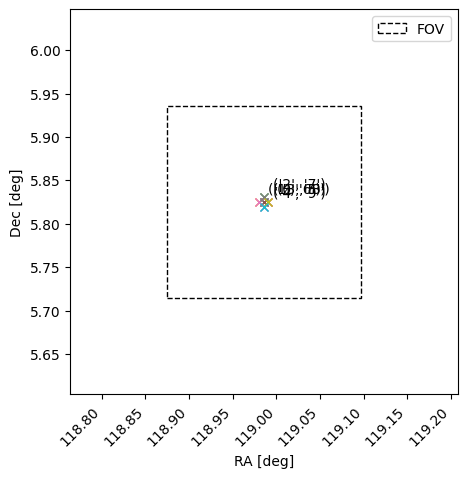

In [6]:
''' Plot the array location pattern on the VISDA array '''

plt.figure(figsize=(5, 5))
ax = plt.subplot()

for i in range(num_observations):
    loc = array_location(i, ra_home= c.ra, dec_home=c.dec) ### call the array_location() function above
    ax.plot(loc[0].value,loc[1].value, 'x')
    if i<5:
        ax.annotate((str(i),str(i+5)), (loc[0].value+0.01,loc[1].value+0.01))

# Add the box to visualize the 1024x1024 FOV
box_width = (1024 * 0.78 * u.arcsec).to(u.degree).value
box_height = box_width
box_left = c.ra.deg - (512 * 0.78 * u.arcsec).to(u.degree).value
box_bottom = c.dec.deg - (512 * 0.78 * u.arcsec).to(u.degree).value
rect = plt.Rectangle((box_left, box_bottom), box_width, box_height,
                     fill=False, edgecolor='black', linestyle='--', label='FOV')
ax.add_patch(rect)

plt.xlabel('RA [deg]')
plt.ylabel('Dec [deg]')

NIR_shape_deg = NIR_ra_shape.to(u.degree) ### set plot limits to the shape of VISDA
plt.xlim(c.ra.deg - (1024*.78*u.arcsec).to(u.degree).value, c.ra.deg + (1024*.78*u.arcsec).to(u.degree).value)
plt.ylim(c.dec.deg - (1024*.78*u.arcsec).to(u.degree).value, c.dec.deg + (1024*.78*u.arcsec).to(u.degree).value)


# Rotate x-axis labels by 45 degrees
plt.xticks(rotation=45, ha='right')
ax.legend()
plt.show()

## Data Volume

10 observations in 2 parts with 5 observations each. Simultaneous VIS and NIR.
- Part 1: smaller NIR subarray for faster readout time and possible time variability measurements.
- Part 2: larger NIR subarray for larger map, but slower readout. 10 VIS frames per integration to match the NIR time as best we can.

In [7]:
''' Constants for this commissioning task '''
num_observations_p1   = 5
num_observations_p2   = 5

regions_VIS           = 2
VIS_xpix              = 200
VIS_ypix              = 200
bits_per_int_VIS      = VIS_xpix * VIS_ypix * regions_VIS * bits_per_pix_VIS * stored_frames_per_int_VIS

num_int_NIR           = 25

### VIS Observations

In [8]:
##### VIS Observation - Part 1 #####
frames_per_int_VIS1     = 1
num_int_VIS1            = 1155

# Time
int_and_reset_time_VIS1 = frame_time_VIS * frames_per_int_VIS1
test_time_VIS1          = num_int_VIS1 * int_and_reset_time_VIS1

# Data
bits_per_sec_VIS1       = bits_per_int_VIS / int_and_reset_time_VIS1
bits_per_sec_comp_VIS1  = bits_per_sec_VIS1 / compression_fractor_VIS
bits_test_total_VIS1    = bits_per_sec_comp_VIS1 * test_time_VIS1 / frames_per_int_VIS1
Gbits_test_packet_VIS1  = bits_test_total_VIS1 / 1E9 * 1.1 * 1.25
downlinks_VIS1          = Gbits_test_packet_VIS1 * 1E9 / (data_rate * 1E6) /60 /pass_time_min 

print('VIS Observations, Part 1:', Gbits_test_packet_VIS1*num_observations_p1, 'Gbits')


##### VIS Observation - Part 2 #####
frames_per_int_VIS2     = 10
num_int_VIS2            = 940

# Time
int_and_reset_time_VIS2 = frame_time_VIS * frames_per_int_VIS2
test_time_VIS2          = num_int_VIS2 * int_and_reset_time_VIS2

# Data
bits_per_sec_VIS2       = bits_per_int_VIS / int_and_reset_time_VIS2
bits_per_sec_comp_VIS2  = bits_per_sec_VIS2 / compression_fractor_VIS
bits_test_total_VIS2    = bits_per_sec_comp_VIS2 * test_time_VIS2 #/ frames_per_int_VIS2
Gbits_test_packet_VIS2  = bits_test_total_VIS2 / 1E9 * 1.1 * 1.25
downlinks_VIS2          = Gbits_test_packet_VIS2 * 1E9 / (data_rate * 1E6) /60 /pass_time_min

print('VIS Observations, Part 2:', Gbits_test_packet_VIS2 * num_observations_p2, 'Gbits')

VIS Observations, Part 1: 6.776000000000002 Gbits
VIS Observations, Part 2: 5.514666666666667 Gbits


### NIR Observations

In [9]:
##### NIR Observation - Part 1 ##### Science window
NIR_xpix_strt_NIR1         = 1968 
NIR_ypix_strt_NIR1         = 824
NIR_xpix_NIR1              = 80
NIR_ypix_NIR1              = 400
stored_frames_per_int_NIR1 = 24
frames_per_int_NIR1        = 24

# Time
frame_time_NIR1            = (NIR_xpix_NIR1+12) * (NIR_ypix_NIR1+2) * 0.00001 #sec
int_and_reset_time_NIR1    = frame_time_NIR1 * (frames_per_int_NIR1+1) # +1 for reset frame
test_time_NIR1             = num_int_NIR * int_and_reset_time_NIR1

# Data
bits_per_int_NIR1          = NIR_xpix_NIR1 * NIR_ypix_NIR1 * regions_NIR * bits_per_pix_NIR * stored_frames_per_int_NIR1
bits_per_sec_NIR1          = bits_per_int_NIR1 / int_and_reset_time_NIR1
bits_per_sec_comp_NIR1     = bits_per_sec_NIR1 / compression_fractor_NIR
bits_test_total_NIR1       = bits_per_sec_comp_NIR1 * test_time_NIR1
Gbits_test_packet_NIR1     = bits_test_total_NIR1 / 1E9 * 1.1 * 1.25
downlinks_NIR1             = Gbits_test_packet_NIR1 * 1E9 / (data_rate * 1E6) /60 /pass_time_min

print('NIR Observations, Part 1:', Gbits_test_packet_NIR1 * num_observations_p1, 'Gbits')

##### NIR Observation - Part 2 ##### Output window
NIR_xpix_strt_NIR2         = 1536 
NIR_ypix_strt_NIR2         = 1
NIR_xpix_NIR2              = 512
NIR_ypix_NIR2              = 2048
stored_frames_per_int_NIR2 = 6
frames_per_int_NIR2        = 6 

# Time
frame_time_NIR2            = (NIR_xpix_NIR2+12) * (NIR_ypix_NIR2+2) * 0.00001 #sec
int_and_reset_time_NIR2    = frame_time_NIR2 * (frames_per_int_NIR2+1) # +1 for reset frame
test_time_NIR2             = num_int_NIR * int_and_reset_time_NIR2

# Data
bits_per_int_NIR2          = NIR_xpix_NIR2 * NIR_ypix_NIR2 * regions_NIR * bits_per_pix_NIR * stored_frames_per_int_NIR2
bits_per_sec_NIR2          = bits_per_int_NIR2 / int_and_reset_time_NIR2
bits_per_sec_comp_NIR2     = bits_per_sec_NIR2 / compression_fractor_NIR
bits_test_total_NIR2       = bits_per_sec_comp_NIR2 * test_time_NIR2
Gbits_test_packet_NIR2     = bits_test_total_NIR2 / 1E9 * 1.1 * 1.25
downlinks_NIR2             = Gbits_test_packet_NIR2 * 1E9 / (data_rate * 1E6) /60 /pass_time_min

print('NIR Observations, Part 2:', Gbits_test_packet_NIR2 * num_observations_p2, 'Gbits')

NIR Observations, Part 1: 1.056 Gbits
NIR Observations, Part 2: 8.650752 Gbits


In [10]:
test_time_VIS1, test_time_NIR1, test_time_VIS2, test_time_NIR2

(231.0, 231.15000000000006, 1880.0, 1879.8500000000001)

### Total Data Volume

In [11]:
### Data volume including parts 1 and 2
num_observations_total = num_observations_p1 + num_observations_p2 # simultaneous vis and nir
Gbits_total = num_observations_p1*(Gbits_test_packet_VIS1+Gbits_test_packet_NIR1) + num_observations_p2*(Gbits_test_packet_VIS2+Gbits_test_packet_NIR2)
downlinks_total = num_observations_p1*(downlinks_VIS1+downlinks_NIR1) + num_observations_p2*(downlinks_VIS2+downlinks_NIR2)
test_time_total = num_observations_p1*max([test_time_VIS1, test_time_NIR1]) + num_observations_p2*max([test_time_VIS2, test_time_NIR2])

print('Test time, total, no slew/overhead time:', test_time_total/60/60, 'hours')
print('Volume, total:', Gbits_total, 'Gbits')
print('Downlinks, total:', downlinks_total)

Test time, total, no slew/overhead time: 2.932152777777778 hours
Volume, total: 21.99741866666667 Gbits
Downlinks, total: 9.16559111111111


In [12]:
### Adding important variables to a dictionary for later
obs_dict = {
    'VIS1': {'test_time': test_time_VIS1, 'xpix': VIS_xpix, 'ypix': VIS_ypix, 'frames_per_int': frames_per_int_VIS1, 'num_int': num_int_VIS1},
    'VIS2': {'test_time': test_time_VIS2, 'xpix': VIS_xpix, 'ypix': VIS_ypix, 'frames_per_int': frames_per_int_VIS2, 'num_int': num_int_VIS2},
    'NIR1': {'test_time': test_time_NIR1, 'xpix_start': NIR_xpix_strt_NIR1, 'xpix': NIR_xpix_NIR1, 'ypix_start': NIR_ypix_strt_NIR1, 'ypix': NIR_ypix_NIR1, 
             'frames_per_int': frames_per_int_NIR1, 'num_int': num_int_NIR},
    'NIR2': {'test_time': test_time_NIR2, 'xpix_start': NIR_xpix_strt_NIR2, 'xpix': NIR_xpix_NIR2, 'ypix_start': NIR_ypix_strt_NIR2, 'ypix': NIR_ypix_NIR2, 
             'frames_per_int': frames_per_int_NIR2, 'num_int': num_int_NIR}
}

## The rest of this notebook should be run for each of the 10 observations. Select an observation number

In [13]:
observation_number = 0  ### zero indexed: possible numbers are 0-9

### defines which observing parameters to call from the dictionary defined above
if observation_number < 5: 
    vis='VIS1'
    nir='NIR1'
if 4 < observation_number < 10: 
    vis='VIS2'
    nir='NIR2'

In [14]:
''' Identify the start time and end time of the observation '''
start_time = Time.now() # starting now. This should get overridden by the scheduler. 
test_time = max(obs_dict[vis]['test_time'], obs_dict[nir]['test_time'])
time_delta = TimeDelta(test_time, format='sec')
end_time = start_time + time_delta

## Begin Simulation

In [ ]:
''' Initialize a simulator object '''
### Set the number of ROIs and their sizes. 
### For now, we cannot define the ROI_size in NIRSim inputs. 
simVIS = VisibleSim(ROI_size=(obs_dict[vis]['xpix'], obs_dict[vis]['ypix']), nROIs=regions_VIS) 
simNIR = NIRSim() # NIRSim(ROI_size=(obs_dict[nir]['xpix'], obs_dict[nir]['ypix']))

In [ ]:
''' Define the center of our observation based on target location and observation number '''
location = array_location(observation_number, c.ra, c.dec)
ra0        = location[0] 
dec0       = location[1] 
theta0     = 0*u.deg ### this is curretly arbitrary


''' Point the simulator to the corrected location '''
###        RA,   DEC,    Theta 
simVIS.point(ra0, dec0, theta0)
simNIR.point(ra0, dec0, theta0) ### this line has an known error. 

In [50]:
''' sim has various attributes you can print out '''
#print(sim.ra, sim.dec, sim.wcs)

''' Notably we have a Catalog of objects visable in the VIS FOV '''
cat = simVIS.source_catalog
#print(cat)

In [51]:
''' identify the correct ROI based on the locations of our targets '''
### This will set the ROI location given an observation number. 
# By default, one ROI is at the center and the second is centered at the next brightest target.
# We instead want to define our own locations. This cell moves one ROI to our primary target. 
# The secondary target is still default the brightest object. 
###

if observation_number>0:
    for i in range(len(cat)):
        ### search the catalog our primary target based on its coordinates. Coordinates are not exact, so we round to 2 decimals.
        if round(c.ra.value,2)==round(cat.ra[i],2) and round(c.dec.value,2)==round(cat.dec[i],2):
            print('Match! Cat index: ', i)
            cat_index = i
    
    ### set corner of primary ROI  
    simVIS.ROI_corners[0] = (cat.row[cat_index]-(VIS_xpix/2), cat.column[cat_index]-(VIS_ypix/2)) 


print('ROI locations [pix]: ', simVIS.ROI_corners)


''' Save ROI locations in sky coordinates for later '''
VISroi0_coord = simVIS.pixel_to_world(simVIS.ROI_corners[0][0], simVIS.ROI_corners[0][1])
VISroi1_coord = simVIS.pixel_to_world(simVIS.ROI_corners[1][0], simVIS.ROI_corners[1][1])

ROI locations [pix]:  [(924.0, 924.0), (918, 544)]


In [16]:
''' We are not yet sure how point NIRDA at the new target location '''

' We are not yet sure how point NIRDA at the new target location '

## Generate Simulated Observation

### VIS Observation

<Axes: title={'center': 'VISDA\n(RA:118.99 deg, Dec:5.83 deg, Roll:0.00 deg)'}, xlabel='Column [pixel]', ylabel='Row [pixel]'>

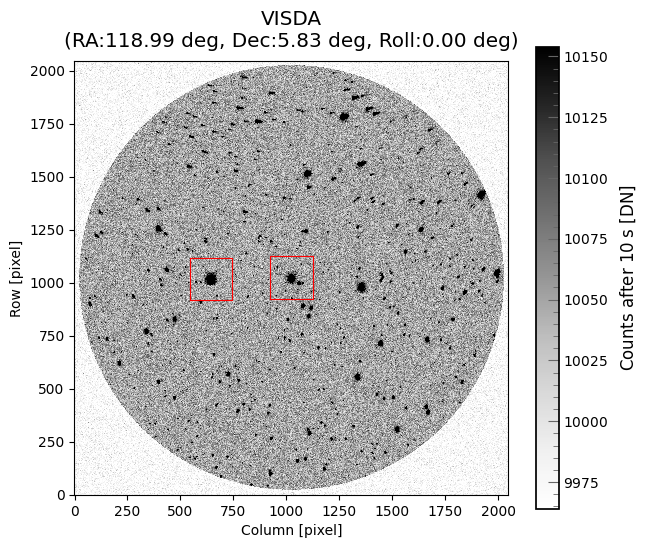

In [52]:
''' Plot the VIS Full Frame Image. ROIs are in red boxes defining the subarrays. '''
simVIS.show_FFI()

In [18]:
''' Create an Observation. '''
### This returns an astropy.io.fits.HDUList array. 
# `nreads` sets how many reads of the detector are coadded together to create a frame.
# `bin_frames` is a shortcut parameter to speed up computation. Must be a factor of nreads. We can ignore this for low nreads. 
# `nframes` sets how many frames will be returned.
# `start_time` indicates the time of observation. 
# `output_type` is set to array, for now. This make it easy to call, but we'll save it as a fits file later. 
###

data = simVIS.observe(nreads=obs_dict[vis]['frames_per_int'], bin_frames=1, nframes=obs_dict[vis]['num_int'], start_time=start_time, output_type="array")

### The shape is: (num ROIs, num frames, nrows, ncolumns)
data.shape

Modeling Pixel Positions: 100%|█████████████████| 15/15 [00:01<00:00,  8.62it/s]


(2, 1050, 200, 200)

array([[<Axes: ylabel='Row\n[subarray pixel]'>, <Axes: >],
       [<Axes: >, <Axes: >]], dtype=object)

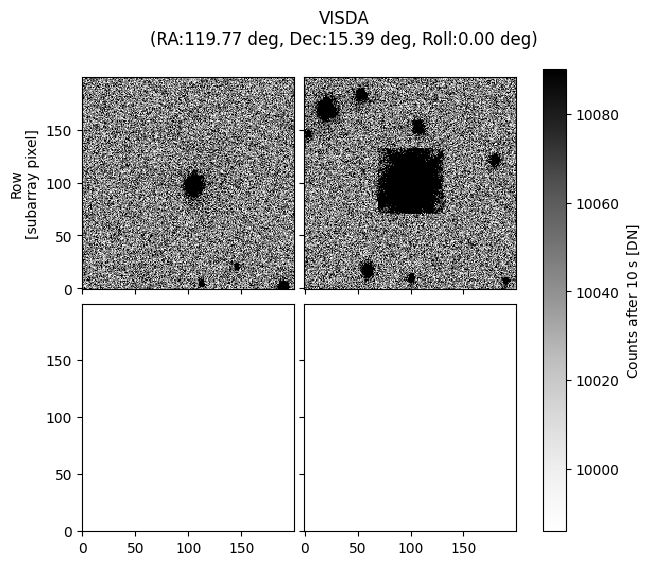

In [19]:
''' Plot our ROIs (regions of interest). ''' 
simVIS.show_ROI()

### NIR Observation

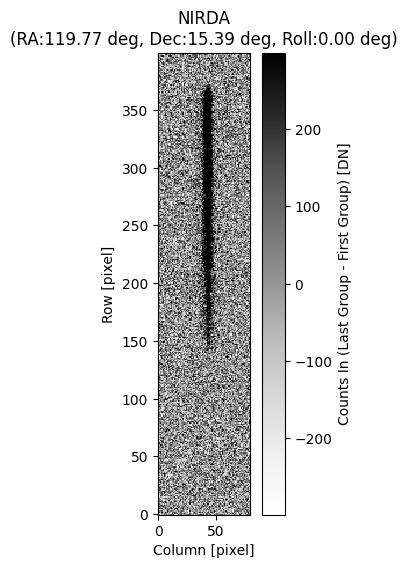

In [20]:
''' Plot the NIRDA subarray '''
simNIR.show_subarray();

In [21]:
''' Create a NIRDA observation. '''
### This returns an astropy.io.fits.HDUList array. The following parameters can be adjusted

# SC_Resets1 : Number of reset frames at the start of the first integration of exposure
# SC_Resets2 : Number of resent frames at the start of 1 through n integrations of exposure
# SC_DropFrames1 : Number of dropped frames after reset of any integration of exposure
# SC_DropFrames2 : Number of dropped frames in every group of integrations of exposure except the last group
# SC_DropFrames3 : Number of dropped frames in the last group of each integration of exposure
# SC_ReadFrames : Number of frames read during each group of integration of exposure
# SC_Groups : Number of groups per integration of exposure
# SC_Integrations : Number of integrations per exposure
# start_time : Time to start the observation. This is only used if returning a fits file, or supplying a flux function.
# noise : bool flag determining whether noise is simulated and included. Default is True.
# jitter : bool flag determining whether jitter is simulated and included. Default is True.
# output_type : String flag to determine the result output. Valid strings are "fits" or "array
###

ROIsize_override = (obs_dict[nir]['xpix'], obs_dict[nir]['ypix']) ### we cannot yet specify this in sim.observe()

data = simNIR.observe(SC_ReadFrames=obs_dict[nir]['frames_per_int'], SC_Integrations=obs_dict[nir]['num_int'], start_time=start_time, output_type="array")

### The shape is: (num ROIs, num frames, nrows, ncolumns)
data.shape

Modeling Pixel Positions: 100%|███████████████████| 9/9 [01:03<00:00,  7.07s/it]


(25, 2, 400, 80)

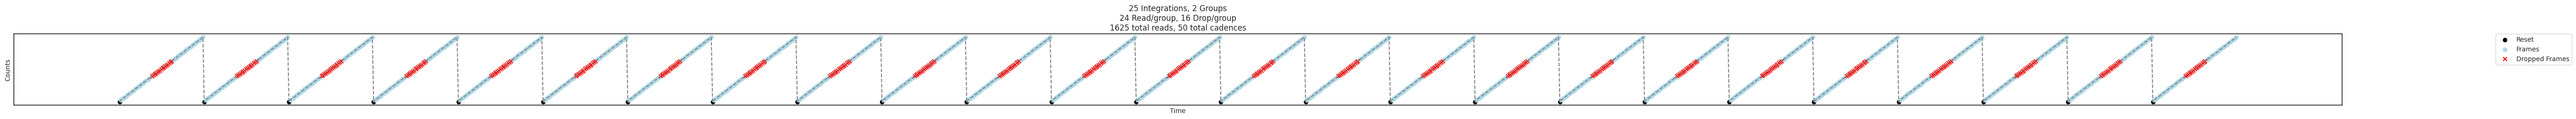

In [22]:
''' Plot the NIRDA integration scheme '''
plot_nirda_integrations(SC_Resets1=1,
    SC_Resets2=1,
    SC_DropFrames1=0,
    SC_DropFrames2=16,
    SC_DropFrames3=0,
    SC_ReadFrames=obs_dict[nir]['frames_per_int'],
    SC_Groups=2,
    SC_Integrations=obs_dict[nir]['num_int']);

## Save the simulated observation

In [23]:
''' Re-Create the observations in the correct format for the .fits file (i.e., output_type set to default) '''
### Before, object_type was array for easy computation in this notebook, but that is not correct for the .fits file
hdulist_vis = simVIS.observe(nreads=obs_dict[vis]['frames_per_int'], bin_frames=1, nframes=obs_dict[vis]['num_int'], start_time=start_time)
hdulist_nir = simNIR.observe(SC_ReadFrames=obs_dict[nir]['frames_per_int'], SC_Integrations=obs_dict[nir]['num_int'], start_time=start_time)


''' Save our simulated observation in a fits file '''
targ = target.replace(" ", "")
VISrois_outfile = "3.18_VISrois_"+str(targ)+"_obs"+str(observation_number)+".fits"
NIRrois_outfile = "3.18_NIRrois_"+str(targ)+"_obs"+str(observation_number)+".fits"
hdulist_vis.writeto(VISrois_outfile, overwrite=True)
hdulist_nir.writeto(NIRrois_outfile, overwrite=True)

Modeling Pixel Positions: 100%|███████████████████| 9/9 [01:03<00:00,  7.05s/it]


In [24]:
### Show what is in our fits file: 
'''
Three FITS file extensions: 
    (1) PRIMARY: information about the simulated observation 
    (2) SCIENCE: data info, images
    (3) ROITABLE: VISDA pixel coordinates of the origin of the subarray, which is defined as the lower left corner
'''

hdul_rois = fits.open(VISrois_outfile) ### or NIRrois_outfile
print(hdul_rois.info())

#print('.')
#print('.')
#print('.')
#print('-- PRIMARY Headers --')
#print(hdul_rois[0].header)

#print('.')
#print('.')
#print('.')
#print('-- SCIENCE Headers --')
#print(hdul_rois[1].header)

#print('.')
#print('.')
#print('.')
#print('-- ROITABLE Headers --')
#print(hdul_rois[2].header)

Filename: 3.18_VISrois_GJ3470_obs0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      23   ()      
  1  SCIENCE       1 ImageHDU        71   (400, 400, 1050)   int64   
  2  ROITABLE      1 BinTableHDU     22   2R x 2C   [D, K]   
None


## Data Products

### RD-B2: table that provides mapping between sky and detector positions to quantify field distortions

### RD-B3: table that provides mapping between sky and detector positions to quantify boresign alignment

'NIR1'

## Generate SOC File

### To run all 10 observations together

In [15]:
for i in range(num_observations):
    observation_number=i

    ### defines which observing parameters to call from the dictionary defined above
    if observation_number < 5: 
        vis, nir ='VIS1', 'NIR1'
    if 4 < observation_number < 10: 
        vis, nir ='VIS2', 'NIR2'
    loc = array_location(i, ra_home=c.ra.deg * u.deg, dec_home=c.dec.deg * u.deg)

    vis_offset = (100*.78*u.arcsec).to(u.degree).value # TOF: this needs to be removed once we determine if and where we want the 2nd VIS ROI

    variables = {
        'visit_id': '0318', ### setting based on task number. Could change. 
        'obs_id': f"{observation_number:03}", ### setting based on observation number. 
        'target': target, 
        'priority': 1, ### all commissioning is priority 1
        'start_time': start_time, 
        'stop_time': end_time, 
        'RA': loc[0].value,
        'DEC': loc[1].value, 
        
        'NIR_AvgGroups': 0, #2, ### check what this is; TOF: Assuming we want all frames returned this should be 0
        'NIR_ROI_StartX': obs_dict[nir]['xpix_start'], #ra0, TOF: this should be pixel coordinates not ra;
        'NIR_ROI_StartY': obs_dict[nir]['ypix_start'], #dec0, TOF: this should be pixel coordinates not dec
        'NIR_ROI_SizeX': obs_dict[nir]['xpix'], 
        'NIR_ROI_SizeY': obs_dict[nir]['ypix'],
        'NIR_SC_Resets1': 1,
        'NIR_SC_Resets2': 1, 
        'NIR_SC_DropFrames1': 0,
        'NIR_SC_DropFrames2': 0, #16, TOF: I don't think we want to drop any frames 
        'NIR_SC_DropFrames3': 0, 
        'NIR_SC_ReadFrames': obs_dict[nir]['frames_per_int'],
        'NIR_targetID': target, 
        'NIR_SC_Groups': 1, #2, TOF: Since we're not Fowler sampling here I think we just want one group per integration
        'NIR_SC_Integrations': obs_dict[nir]['num_int'], 
        
        'ffi_flag': 0, # this task does not require full frame images
        'VIS_StarRoiDetMethod': 0,  ### 0: monitor stars at positions defined in [PredefinedStarRoiRa, PredefinedStarRoiDec]. 1: Run star detection algorithm on first image and obtain star ROIs from results.
        'VIS_FramesPerCoadd': obs_dict[vis]['frames_per_int'], 
        'VIS_NumTotalFramesRequested': obs_dict[vis]['num_int'] * obs_dict[vis]['frames_per_int'], 
        'VIS_TargetRA': c.ra.deg, 
        'VIS_TargetDEC': c.dec.deg, 
        'VIS_IncludeFieldSolnsInResp': 1, ### Determines whether the Ra/Dec/Rot values calculated for each frame in the visible science collect will be included in the response message [1] or not [0].
        'VIS_StarRoiDimension': [obs_dict[vis]['xpix']], 
        'VIS_MaxNumStarRois': 0, ### max number of star ROIs that will be used for coadding signal from target stars if StarRoiDetMethod == 1.
        'VIS_numPredefinedStarRois': regions_VIS, ### If StarRoiDetMethod==0, this is the number of [RA, DEC] coordinates contained in the PredefinedStarRoiRA and PredefinedStarRoiDEC vectors.
        'VIS_PredefinedStarRoiRa': [c.ra.deg, c.ra.deg - vis_offset], ### currently defining as corner of ROI. We may update this to be ROI centers.
        'VIS_PredefinedStarRoiDec': [c.dec.deg, c.dec.deg], 
        'VIS_targetID': target, 
        'VIS_NumExposuresMax': obs_dict[vis]['num_int'] * obs_dict[vis]['frames_per_int'], 
        'VIS_ExposureTime_us': frame_time_VIS * 1000000  
    }

    '''Generate the SOC .xml file'''

    output_soc_file = variables['visit_id']+'_'+variables['obs_id']+'_SOC.xml' 
    generate_task_plan(variables, output_soc_file)

### To run a single observation

In [ ]:
'''Here we define the information required for scheduling the observation.'''
### Some variables may be removed/added/changed. 
### The format and variables in the SOC files are currently be defined. 
### This function and variables should be revisited once the format is defined. 

variables = {
    'ffi_flag': 0, # this task does not require full frame images
    'visit_id': '0318', ### setting based on task number. Could change. 
    'obs_id': f"{observation_number:03}", ### setting based on observation number. 
    'target': target, 
    'priority': 1, ### all commissioning is priority 1
    'start_time': start_time, 
    'stop_time': end_time, 
    'RA': ra0.deg,
    'DEC': dec0.deg, 
    
    'NIR_AvgGroups': 2, ### check what this is
    'NIR_ROI_StartX': ra0, 
    'NIR_ROI_StartY': dec0, 
    'NIR_ROI_SizeX': obs_dict[nir]['xpix'], 
    'NIR_ROI_SizeY': obs_dict[nir]['ypix'],
    'NIR_SC_Resets1': 1,
    'NIR_SC_Resets2': 1, 
    'NIR_SC_DropFrames1': 0,
    'NIR_SC_DropFrames2': 16,
    'NIR_SC_DropFrames3': 0, 
    'NIR_SC_ReadFrames': obs_dict[nir]['frames_per_int'],
    'NIR_targetID': target, 
    'NIR_SC_Groups': 2,
    'NIR_SC_Integrations': obs_dict[nir]['num_int'], 
    
    'VIS_StarRoiDetMethod': 0,  ### 0: monitor stars at positions defined in [PredefinedStarRoiRa, PredefinedStarRoiDec]. 1: Run star detection algorithm on first image and obtain star ROIs from results.
    'VIS_FramesPerCoadd': obs_dict[vis]['frames_per_int'], 
    'VIS_NumTotalFramesRequested': obs_dict[vis]['num_int'], 
    'VIS_TargetRA': ra0, 
    'VIS_TargetDEC': dec0, 
    'VIS_IncludeFieldSolnsInResp': 1, ### Determines whether the Ra/Dec/Rot values calculated for each frame in the visible science collect will be included in the response message [1] or not [0].
    'VIS_StarRoiDimension': [obs_dict[vis]['xpix'], obs_dict[vis]['ypix']], 
    'VIS_MaxNumStarRois': '', ### max number of star ROIs that will be used for coadding signal from target stars if StarRoiDetMethod == 1.
    'VIS_numPredefinedStarRois': regions_VIS, ### If StarRoiDetMethod==0, this is the number of [RA, DEC] coordinates contained in the PredefinedStarRoiRA and PredefinedStarRoiDEC vectors.
    'VIS_PredefinedStarRoiRa': [VISroi0_coord[0], VISroi1_coord[0]], ### currently defining as corner of ROI. We may update this to be ROI centers.
    'VIS_PredefinedStarRoiDec': [VISroi0_coord[1], VISroi1_coord[1]], 
    'VIS_targetID': target, 
    'VIS_NumExposuresMax': obs_dict[vis]['num_int'], 
    'VIS_ExposureTime_us': frame_time_VIS * 1000000  
}

In [ ]:
'''Generate the SOC .xml file'''

output_soc_file = variables['visit_id']+'_'+variables['obs_id']+'_SOC.xml' 
generate_task_plan(variables, output_soc_file)